In [43]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # for data visualization
import seaborn as sns # for statistical data visualization
%matplotlib inline
from sklearn.cluster import KMeans

In [44]:
data = pd.read_csv('/content/Parent_Table.csv')

In [45]:
data.head()

,Keyword ID,Topic,Keyword,Position,Previous position,Search Volume,Keyword Difficulty,CPC,Traffic,Traffic (%),Traffic Cost,Competition,Number of Results,Timestamp,Keyword Intents,Position Type
0,1,PMP Exam & Certification | Flat 40% Off - Enro...,what is my new renewal date after i reneew pmp,1,1,480,16,0.0,41,0.0,0,0.0,57300,01-01-2025,informational,AI overview
1,1,PMP Exam & Certification | Flat 40% Off - Enro...,what is rfpin project management,1,1,320,31,0.0,27,0.0,0,0.0,59700000,14-01-2025,informational,AI overview
2,1,PMP Exam & Certification | Flat 40% Off - Enro...,what is a rom in project management,1,1,90,25,0.0,15,0.0,0,0.0,80800000,31-12-2024,informational,AI overview
3,1,PMP Exam & Certification | Flat 40% Off - Enro...,pmp post assessment questions,1,1,480,26,0.0,119,0.0,0,0.0,7970000,01-01-2025,informational,Organic
4,1,PMP Exam & Certification | Flat 40% Off - Enro...,the benefits of effective project management,1,1,480,35,0.0,119,0.0,0,0.0,1370000000,14-01-2025,informational,Organic


In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29955 entries, 0 to 29954
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Keyword ID          29955 non-null  int64  
 1   Topic               29955 non-null  object 
 2   Keyword             29954 non-null  object 
 3   Position            29955 non-null  int64  
 4   Previous position   29955 non-null  int64  
 5   Search Volume       29955 non-null  int64  
 6   Keyword Difficulty  29955 non-null  int64  
 7   CPC                 29955 non-null  float64
 8   Traffic             29955 non-null  int64  
 9   Traffic (%)         29955 non-null  float64
 10  Traffic Cost        29955 non-null  int64  
 11  Competition         29955 non-null  float64
 12  Number of Results   29955 non-null  int64  
 13  Timestamp           29955 non-null  object 
 14  Keyword Intents     29955 non-null  object 
 15  Position Type       29955 non-null  object 
dtypes: f

In [47]:
data.describe()

,Keyword ID,Position,Previous position,Search Volume,Keyword Difficulty,CPC,Traffic,Traffic (%),Traffic Cost,Competition,Number of Results
count,29955.000000,29955.000000,29955.000000,2.995500e+04,29955.000000,29955.000000,29955.000000,29955.000000,29955.000000,29955.000000,2.995500e+04
mean,24.363378,2.714171,2.708363,1.614955e+03,48.526189,1.613886,40.565014,0.000993,72.619396,0.079032,5.648471e+08
std,8.302153,3.145048,3.471573,1.759213e+04,16.896798,3.773438,220.989140,0.015175,670.370586,0.151476,1.800053e+09
min,1.000000,1.000000,0.000000,3.000000e+01,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,19.000000,1.000000,1.000000,2.100000e+02,37.000000,0.000000,11.000000,0.000000,0.000000,0.000000,2.000000e+07
50%,31.000000,1.000000,1.000000,4.800000e+02,48.000000,0.070000,17.000000,0.000000,1.000000,0.010000,9.720000e+07
75%,31.000000,3.000000,3.000000,1.000000e+03,59.000000,2.110000,33.000000,0.000000,39.000000,0.080000,3.670000e+08
max,31.000000,46.000000,71.000000,1.830000e+06,100.000000,237.880000,27450.000000,1.910000,59631.000000,1.000000,2.527000e+10


In [48]:
data = data[["Search Volume","Traffic"]] # find correlation plots in python

In [49]:
data.head()

,Search Volume,Traffic
0,480,41
1,320,27
2,90,15
3,480,119
4,480,119


In [50]:
X = data
y = data[["Traffic"]]

In [51]:
# from sklearn.preprocessing import StandardScaler

# X = data[['Search Volume', 'Traffic']]

# scaler = StandardScaler()

# X = scaler.fit_transform(X)

**Transforming data**

In [52]:

# data['Log_Search_Volume'] = np.log1p(data['Search Volume'])
# data['Log_Traffic'] = np.log1p(data['Traffic'])

# X = data[['Log_Search_Volume','Log_Traffic']]

**Elbow method**

In [53]:
inertia = []
for n in range(1 , 15):
    algorithm = (KMeans(n_clusters = n ,init='k-means++', n_init = 10 ,max_iter=300,
                        tol=0.0001,  random_state= 111  , algorithm='elkan') )
    algorithm.fit(X)
    inertia.append(algorithm.inertia_)

In [54]:
import warnings
warnings.filterwarnings('ignore')

In [55]:
import plotly as py
import plotly.graph_objs as go

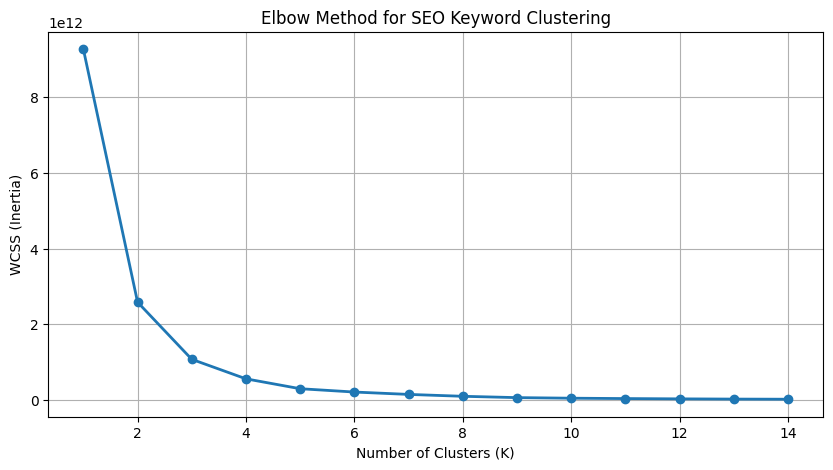

In [56]:
plt.figure(figsize=(10,5))

plt.plot(np.arange(1,15), inertia, marker='o', linewidth=2)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for SEO Keyword Clustering")
plt.grid(True)

plt.show()

In [57]:
algorithm = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init=10,
    max_iter=300,
    tol=0.0001,
    random_state=111,
    algorithm='elkan'
)

algorithm.fit(X)

labels1 = algorithm.labels_

centroids1 = algorithm.cluster_centers_

In [58]:
h = 1000

x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = algorithm.predict(np.c_[xx.ravel(), yy.ravel()])

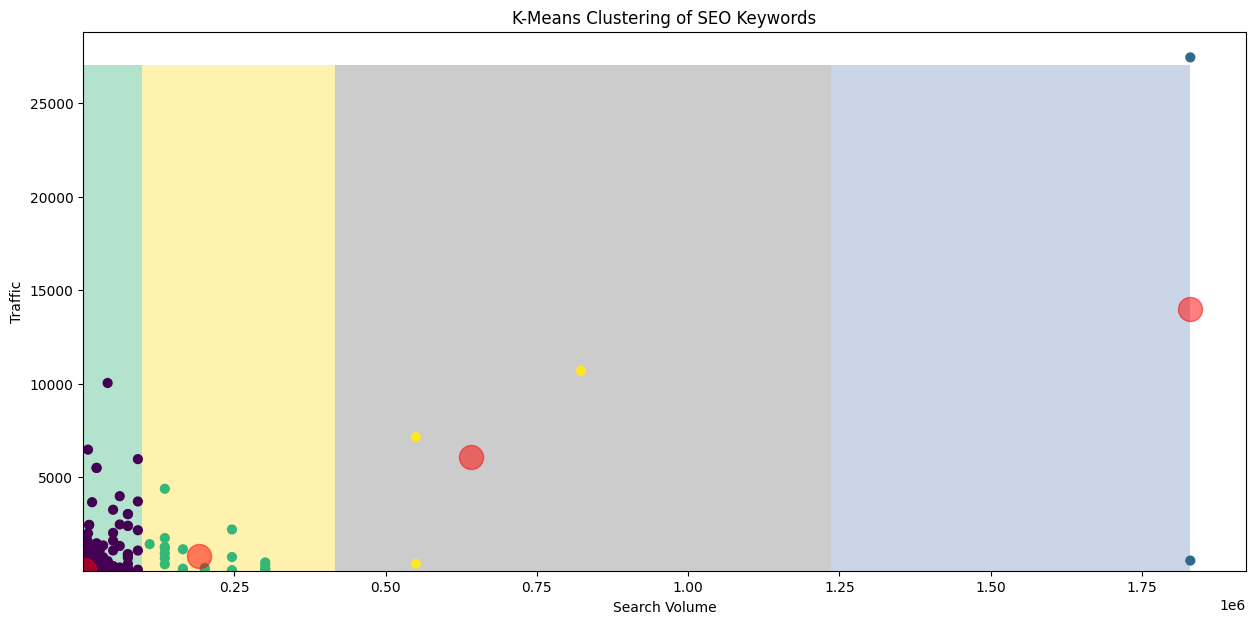

In [59]:
plt.figure(1, figsize=(15,7))
plt.clf()

Z = Z.reshape(xx.shape)

plt.imshow(
    Z,
    interpolation='nearest',
    extent=(xx.min(), xx.max(), yy.min(), yy.max()),
    cmap=plt.cm.Pastel2,
    aspect='auto',
    origin='lower'
)

plt.scatter(
    x='Search Volume',
    y='Traffic',
    data=data,
    c=labels1,
    s=40
)

plt.scatter(
    x=centroids1[:,0],
    y=centroids1[:,1],
    s=300,
    c='red',
    alpha=0.5
)

plt.xlabel("Search Volume")
plt.ylabel("Traffic")
plt.title("K-Means Clustering of SEO Keywords")

plt.show()